Task 3. Geometric Transformations   

Pick a personal reference number: the last 2 digits of your employee ID (or, if you don't have one yet, the last 2 digits of your phone number). Compute angle = (your number) x 3 degrees and scale = 1 + (last digit of your number / 10). 

Apply translation, this rotation, this scale factor, and one affine transform to your objects photo. State the reference number and computed values explicitly in your notebook so your mentor can double check them. 

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
reference_number = 42

angle = reference_number * 3
scale = 1 + (reference_number % 10) / 10

In [5]:

print("Reference Number :", reference_number)
print("Rotation Angle   :", angle)
print("Scale Factor     :", scale)


Reference Number : 42
Rotation Angle   : 126
Scale Factor     : 1.2


In [19]:
img = cv2.imread("raw_captures/Object.jpeg")

row , col = img.shape[:2]

In [20]:
tx = 100
ty = 60

translation_matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(
    img,
    translation_matrix,
    (col, row)
)

In [23]:
center = (col//2, row//2)
rotation_matrix = cv2.getRotationMatrix2D(
    center,
    angle,
    scale
)

rotated_scaled = cv2.warpAffine(
    img,
    rotation_matrix,
    (col,row)
)

In [25]:
pts1 = np.float32([
    [50,50],
    [200,50],
    [50,200]
])

pts2 = np.float32([
    [80,70],
    [220,80],
    [70,220]
])

affine_matrix = cv2.getAffineTransform(
    pts1,
    pts2
)

affine = cv2.warpAffine(
    img,
    affine_matrix,
    (col, row)
)


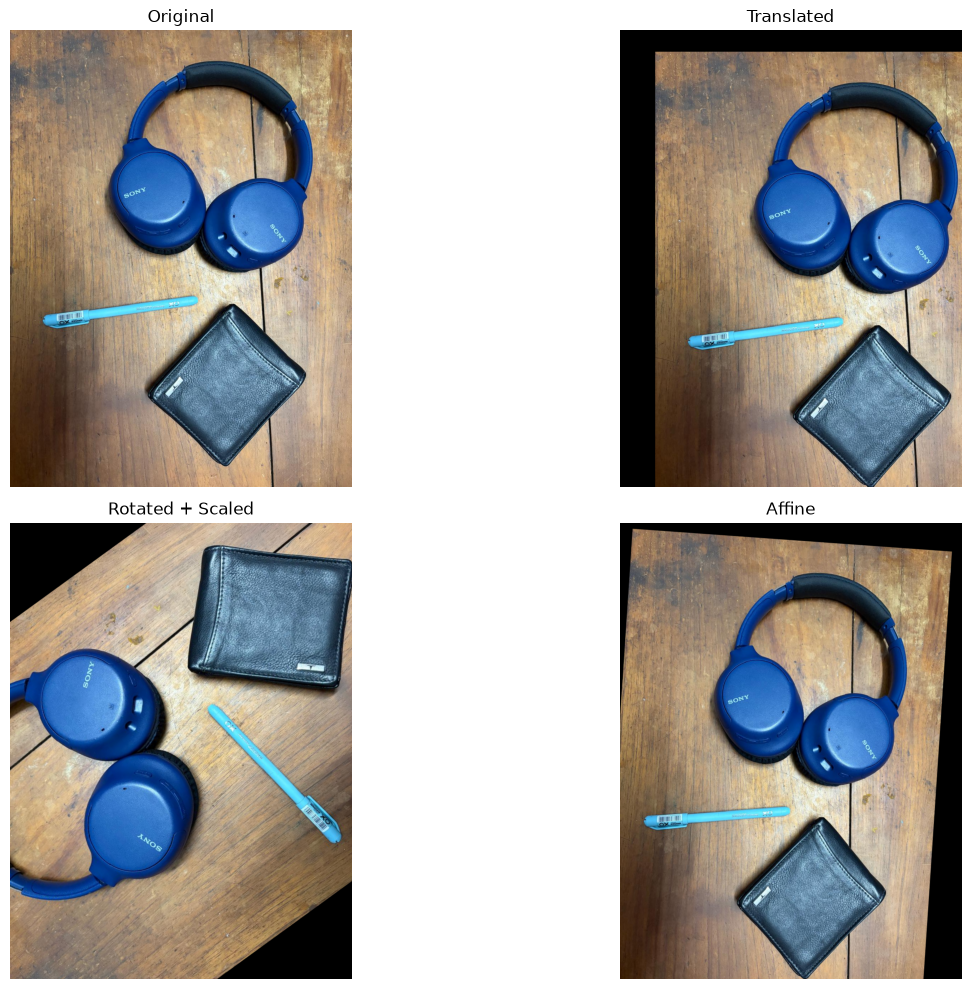

In [26]:
images = [
    ("Original", img),
    ("Translated", translated),
    ("Rotated + Scaled", rotated_scaled),
    ("Affine", affine)
]

plt.figure(figsize=(15,10))

for i, (title, image) in enumerate(images):
    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Translation: Shifted the image 100 pixels right and 60 pixels down without changing its orientation or size.
Rotation: Rotated the image by 126° about its center.
Scaling: Enlarged the image by a factor of 1.5, making objects appear larger.
Affine Transformation: Warped the image by moving three reference points, introducing a combination of translation, scaling, rotation, and shear while keeping straight lines straight.